<a href="https://colab.research.google.com/github/meir523/bnn-speech-denoising/blob/main/Main_BNN_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#   Speech Denoising Using BNN

## Main notebook for Bayesian Learning Project

Meir Gamla ID 311486781

## Setup and Imports

In [ ]:
!pip install pesq pystoi

  Preparing metadata (setup.py) ... done
  Created wheel for pesq: filename=pesq-0.0.4-cp312-cp312-linux_x86_64.whl size=284117 sha256=d938da7d580ed44260570e04c2167f6848ba93ba4ee2ca236e70f94ed0e843ff
  Stored in directory: /root/.cache/pip/wheels/9b/d4/a4/9cf3512534cd47ce4a036d1593ee4013f2bf7509e631a147a3
Successfully built pesq


In [ ]:
# Libraries
import sys
import os
import numpy as np
import pandas as pd
import importlib
import zipfile
import subprocess
import random
import matplotlib.pyplot as plt
import IPython.display as ipd
import torch
from tqdm.notebook import tqdm



# Define project dirs & paths
# Check if running in Colab
if 'google.colab' in sys.modules:
    from google.colab import drive
    if not os.path.exists('bnn-speech-denoising'):
        !git clone https://github.com/meir523/bnn-speech-denoising.git
        !cd bnn-speech-denoising && git lfs pull
    project_dir = '/content/bnn-speech-denoising'

else:
    # Local execution
    project_dir = '.'

print(f"Working directory set to: {project_dir}")

data_ZIP_path = os.path.join(project_dir, 'data_compressed.zip')
data_dir = "./data"
src_dir = os.path.join(project_dir, 'src')
models_dir = os.path.join(project_dir, 'models')


# Add project root to Python path
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

# Clear import caches
importlib.invalidate_caches()

# Import local modules
import data_loader, models, metrics, utils, train, inference
importlib.reload(data_loader)
importlib.reload(models)
importlib.reload(metrics)
importlib.reload(utils)
importlib.reload(train)
importlib.reload(inference)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory set to: /content/drive/MyDrive/לימודים/תואר שני/סמסטר3/בייסיאניות/פרויקט/bnn-speech-denoising


<module 'inference' from '/content/drive/MyDrive/לימודים/תואר שני/סמסטר3/בייסיאניות/פרויקט/bnn-speech-denoising/src/inference.py'>

In [ ]:
# Dataset Structure
NUM_SPEAKERS = 20                     # Number of speakers in the dataset (I've used all the available data for better learning.)
FILES_PER_SPEAKER = 10                # Number of audio files per speaker
TRAIN_RATIO = 0.7                     # Portion of data used for training
VAL_RATIO = 0.15                      # Portion used for validation
SNR_LEVELS = [0, 5, 10]               # Noise levels used to create training examples with varying difficulty

# Feature Extraction
SR = 16000                            # Sampling rate (good quality, not heavy load)
N_FFT = 512                           # FFT size for STFT feature extraction (determines frequency resolution)
HOP_LENGTH = 256                      # Progress distance between successive FFT windows
FREQ_BINS = N_FFT // 2 + 1            # Number of unique frequency bins for real-valued signals
CONTEXT_FRAMES = 3                    # Number of neighboring frames added as context
WINDOW_SIZE = 2 * CONTEXT_FRAMES + 1  # 3 frames back + current + 3 frames forward = 7

# Models
HIDDEN_DIM = 256                      # Size of the hidden layer in the NNs
INPUT_DIM = FREQ_BINS * WINDOW_SIZE   # 257 * 7 = 1799, Input dimension for NNs
OUTPUT_DIM = FREQ_BINS                # 257, Output dimension for NNs
LEARNING_RATE = 1e-3                  # Learning rate for training
BATCH_SIZE = 128                      # Batch size for GPU training and stable optimization
EPOCHS = 50                           # Number of training epochs
# BNN
MC_SAMPLES_TRAIN = 5                  # Number of forward iterations for MCMC sample of BNN's training
MC_SAMPLES_INFERENCE = 30             # Number of inference iterations for MCMC sample of BNN
MAX_BETA = 0.0001                     # Normalization for KL in BNN loss function
PRIOR_STD = 0.1                       # STD Prior for the weight's distributions in BNN
PRIOR_TYPE = 'gaussian'               # Can be 'gaussian' or 'laplace'

# General
RANDOM_SEED = 42                      # Fixed seed for reproducibility of experiments
utils.set_seed(RANDOM_SEED)

# Data Load & Preprocess


Preparing the dataset for training and evaluation. According to requirements, we select a subset of 10 speakers, utilizing 5 utterances per speaker.

To simulate challenging real-world environments and evaluate the models' robustness, we mix the clean speech signals with wind noise. The mixing is performed at three different Signal-to-Noise Ratio (SNR) levels: 0dB, 5dB, and 10dB. A 0dB SNR represents an extremely noisy environment where the noise power equals the speech power (Using SNR means that the noise is measured and mixed **in proportion** to the volume of speech in the specific file.).

The output of this process is a structured dataset containing the clean speech, the injected wind noise, and the resulting mixed signals, tagged by speaker ID to ensure no data leakage occurs between the train and test splits.

In [ ]:
# Extract the dataset (if it hasn't been extracted yet)
if not os.path.exists(data_dir):
    if os.path.exists(data_ZIP_path):
        print("Extracting data...")
        with zipfile.ZipFile(data_ZIP_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Extraction complete.")
    else:
        print("Error: Zip file not found. Make sure the path is correct.")
else:
    print("Data directory already exists. Ready to go.")

Extracting data...
Extraction complete.


In [ ]:
# Retrieve file paths
timit_files = data_loader.get_timit_files(data_dir, num_speakers=NUM_SPEAKERS, files_per_speaker=FILES_PER_SPEAKER)
wind_files = data_loader.get_wind_files(data_dir)

print(f"Loaded {len(timit_files)} speech files and {len(wind_files)} wind noise files.")

dataset = []

# Iterate over all selected speech files to generate mixtures
for speech_path in timit_files:
    # Extract speaker ID for train/test splitting
    speaker_id = os.path.basename(os.path.dirname(speech_path))
    file_name = os.path.basename(speech_path)

    for snr in SNR_LEVELS:
        # Randomly select a wind noise file for each mixture to ensure variance
        wind_path = random.choice(wind_files)

        # Mix the signals
        mixed_signal, clean_signal, noise_signal = data_loader.load_and_mix(
            speech_path, wind_path, target_snr_db=snr, sr=SR
        )

        # Append the processed data to dataset list
        dataset.append({
            'speaker_id': speaker_id,
            'file_name': file_name,
            'snr': snr,
            'clean': clean_signal,
            'mixed': mixed_signal,
            'noise': noise_signal
        })

print(f"Successfully generated {len(dataset)} mixed audio samples across {len(SNR_LEVELS)} SNR levels.")

Loaded 200 speech files and 100 wind noise files.
Successfully generated 600 mixed audio samples across 3 SNR levels.


### Example

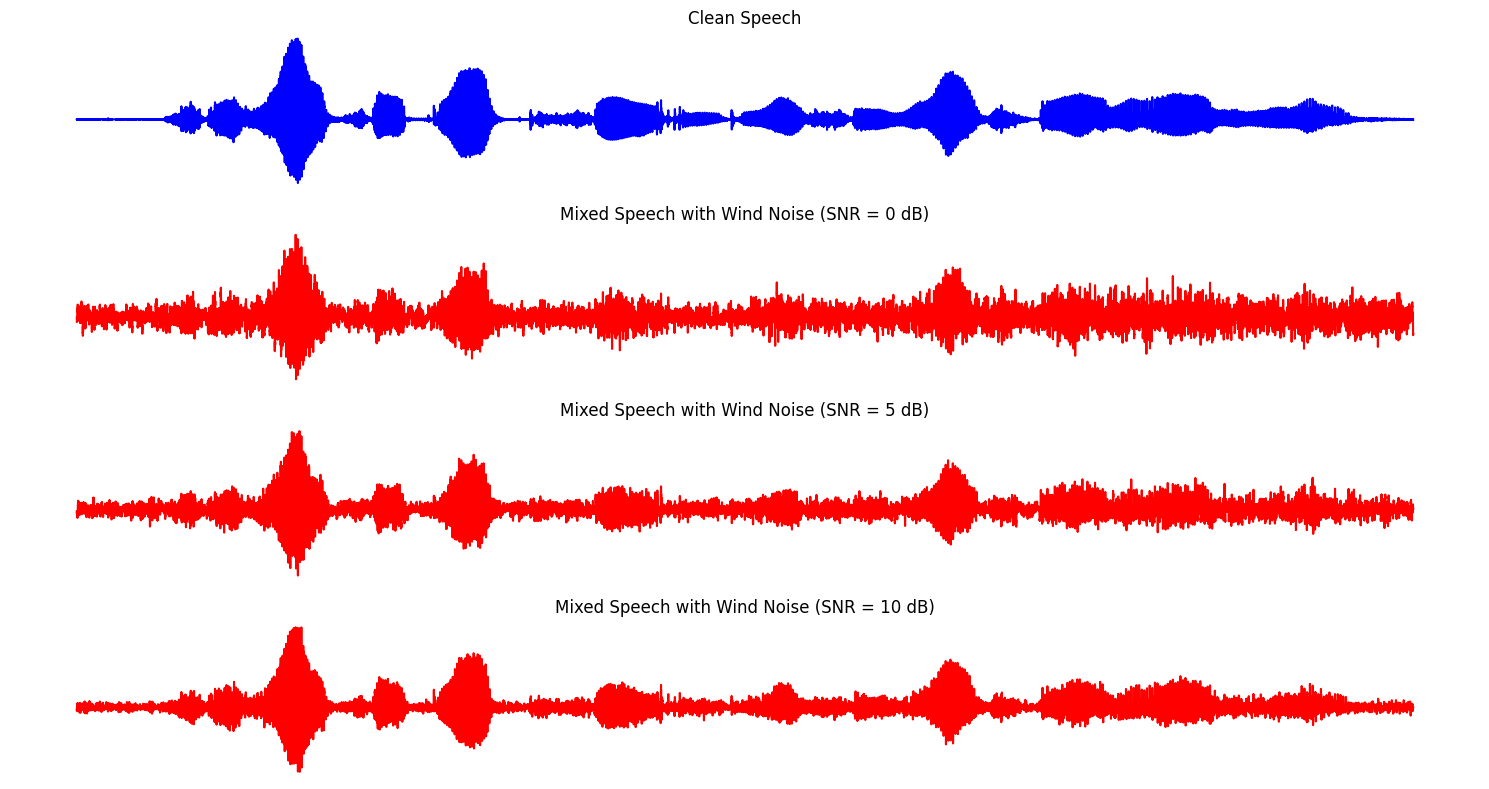

--- Audio Playback ---
Clean Speech:



Noisy Speech (SNR: 0 dB):



Noisy Speech (SNR: 5 dB):



Noisy Speech (SNR: 10 dB):


In [ ]:
# Select first speaker & file
sample_file_name = dataset[0]['file_name']
sample_speaker = dataset[0]['speaker_id']

# Get the clean and mixed versions for this file
sample_data = [item for item in dataset if item['file_name'] == sample_file_name and item['speaker_id'] == sample_speaker]

# Plot the waveforms
plt.figure(figsize=(15, 8))

# Plot Clean Speech
plt.subplot(len(SNR_LEVELS) + 1, 1, 1)
clean_signal = sample_data[0]['clean']
plt.plot(clean_signal, color='blue')
plt.title('Clean Speech')
plt.axis('off')

# Plot mixed speech for each SNR level
for i, item in enumerate(sample_data):
    plt.subplot(len(SNR_LEVELS) + 1, 1, i + 2)
    plt.plot(item['mixed'], color='red')
    plt.title(f'Mixed Speech with Wind Noise (SNR = {item["snr"]} dB)')
    plt.axis('off')

plt.tight_layout()
plt.show()

# Display Audio Players
print("--- Audio Playback ---")
print("Clean Speech:")
display(ipd.Audio(clean_signal, rate=SR))

for item in sample_data:
    print(f"\nNoisy Speech (SNR: {item['snr']} dB):")
    display(ipd.Audio(item['mixed'], rate=SR))

## Feature Extraction

Our pre-processing consists of computing the **Short-Time Fourier Transform (STFT)** to extract magnitude spectrograms, which will serve as the input features for both the DNN and BNN models (MFCCs are frequently used for general speech modeling, but they heavily compress the spectral information).

In [ ]:
# Feature extraction
data_loader.process_dataset_features(dataset, n_fft=N_FFT, hop_length=HOP_LENGTH)
print(f"Processed features for {len(dataset)} items in the dataset.")

# Show an example of the processed data structure
print("\nExample of a processed item:")
example_item = dataset[0]
for k, v in example_item.items():
    if isinstance(v, np.ndarray):
        print(f"  {k}: shape {v.shape}, dtype {v.dtype}")
    else:
        print(f"  {k}: {v}")

Processed features for 600 items in the dataset.

Example of a processed item:
  speaker_id: FCJF0
  file_name: SA1.wav
  snr: 0
  clean: shape (46797,), dtype float32
  mixed: shape (46797,), dtype float32
  noise: shape (46797,), dtype float32
  clean_mag: shape (257, 183), dtype float32
  clean_phase: shape (257, 183), dtype float32
  mixed_mag: shape (257, 183), dtype float32
  mixed_phase: shape (257, 183), dtype float32


## Data Random Split

Train-Validation-Test

In [ ]:
train_data, val_data, test_data = data_loader.split_dataset_by_speaker(dataset_list=dataset, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, seed=RANDOM_SEED)

Split complete. Speakers: 14 Train, 3 Val, 3 Test.
Samples: 420 Train, 90 Val, 90 Test.


## Dataset Adjustment and Batching

To train our models effectively, we must format the extracted STFT spectrograms into structured input-target pairs. We implement a custom PyTorch `Dataset` that iterates over the processed audio files and extracts sliding context windows from the noisy magnitude spectrograms.

Each input vector consists of a central frame concatenated with its surrounding context frames, providing the network with the temporal awareness necessary to distinguish sustained speech from transient wind noise. The corresponding target is simply the clean magnitude of the central frame.

Finally, PyTorch `DataLoader` objects are instantiated to handle mini-batching, shuffling (for the training set), and efficient data transfer to the GPU during the training loop.

In [ ]:
print("Creating DataLoaders...")

train_loader, val_loader, test_loader = data_loader.create_data_loaders(train_data, val_data, test_data, batch_size=BATCH_SIZE, context_frames=CONTEXT_FRAMES)

print(f"Train Loader: {len(train_loader)} batches")
print(f"Val Loader: {len(val_loader)} batches")
print(f"Test Loader: {len(test_loader)} batches")

Creating DataLoaders...
Train Loader: 613 batches
Val Loader: 130 batches
Test Loader: 136 batches


# DNN



## Training

Using compute device: cuda
Model Input Dimension: 1799
Model Output Dimension: 257

--- Starting DNN Training ---
Epoch [1/50] | Train Loss: 0.0097 | Val Loss: 0.0052
Epoch [2/50] | Train Loss: 0.0045 | Val Loss: 0.0044
Epoch [3/50] | Train Loss: 0.0037 | Val Loss: 0.0038
Epoch [4/50] | Train Loss: 0.0032 | Val Loss: 0.0035
Epoch [5/50] | Train Loss: 0.0029 | Val Loss: 0.0034
Epoch [6/50] | Train Loss: 0.0027 | Val Loss: 0.0033
Epoch [7/50] | Train Loss: 0.0025 | Val Loss: 0.0036
Epoch [8/50] | Train Loss: 0.0025 | Val Loss: 0.0032
Epoch [9/50] | Train Loss: 0.0024 | Val Loss: 0.0031
Epoch [10/50] | Train Loss: 0.0023 | Val Loss: 0.0033
Epoch [11/50] | Train Loss: 0.0022 | Val Loss: 0.0029
Epoch [12/50] | Train Loss: 0.0021 | Val Loss: 0.0030
Epoch [13/50] | Train Loss: 0.0021 | Val Loss: 0.0029
Epoch [14/50] | Train Loss: 0.0020 | Val Loss: 0.0029
Epoch [15/50] | Train Loss: 0.0019 | Val Loss: 0.0030
Epoch [16/50] | Train Loss: 0.0019 | Val Loss: 0.0030
Epoch [17/50] | Train Loss: 0.0

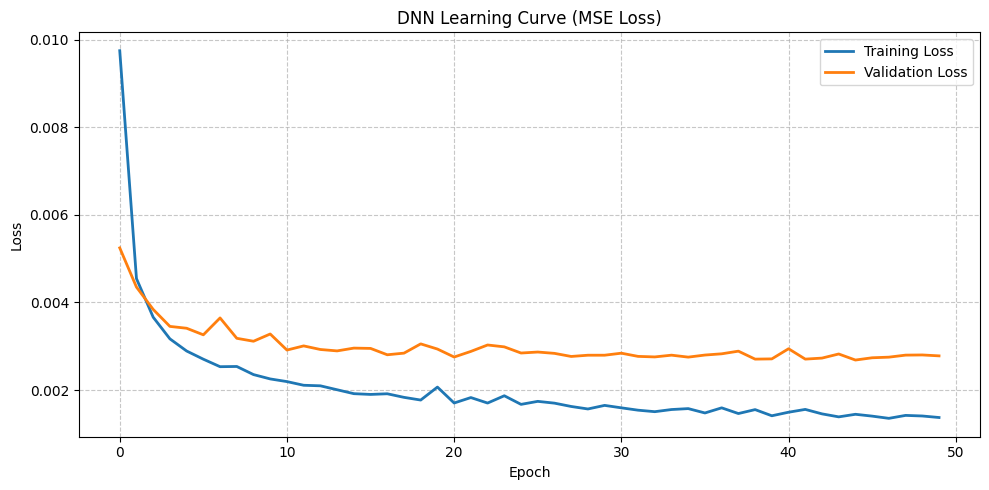

In [ ]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")

print(f"Model Input Dimension: {INPUT_DIM}")
print(f"Model Output Dimension: {OUTPUT_DIM}")

# Initializing the deterministic baseline network (DNN)
dnn_model = models.SpeechDNN(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, output_dim=OUTPUT_DIM)

# Running the training process
print("\n--- Starting DNN Training ---")
dnn_history = train.train_dnn(
    model=dnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    device=device
)

# Save the trained parameters
torch.save(dnn_model.state_dict(), os.path.join(models_dir, 'dnn_model.pth'))
print("DNN model saved successfully to the 'models' directory.")

# Plotting the convergence graph
utils.plot_learning_curve(dnn_history, title='DNN Learning Curve (MSE Loss)')

## DNN Example: Inference and Audio Reconstruction

To evaluate the perceptual quality of our model, we run a forward pass on an unseen noisy sample from the test set. The network predicts the clean magnitude spectrogram from the sliding context windows. We then combine this predicted magnitude with the phase of the original noisy signal and apply the Inverse Short-Time Fourier Transform (ISTFT) to reconstruct the audio waveform.

In [ ]:
# Select a sample from the test set
test_sample = test_data[0]

# Run inference
predicted_audio = inference.run_inference(dnn_model, test_sample, CONTEXT_FRAMES, hop_length=HOP_LENGTH, device=device)

# Display interactive audio players
print(f"--- Audio Results (SNR: {test_sample['snr']} dB) ---")
print("1. Clean Original Speech:")
display(ipd.Audio(test_sample['clean'], rate=SR))

print("2. Noisy Speech (Input):")
display(ipd.Audio(test_sample['mixed'], rate=SR))

print("3. DNN Enhanced Speech (Output):")
display(ipd.Audio(predicted_audio, rate=SR))

--- Audio Results (SNR: 0 dB) ---
1. Clean Original Speech:


2. Noisy Speech (Input):


3. DNN Enhanced Speech (Output):


# BNN

## Training

Configurations and parameters are the same as DNN

Using compute device: cuda
Model Input Dimension: 1799
Model Output Dimension: 257

--- Starting BNN Training ---
Epoch [1/50] | ELBO: 0.0246 (MSE: 0.0246, KL(unscaled): 330529.5749) | Beta: 0.00000
Epoch [2/50] | ELBO: 0.0158 (MSE: 0.0143, KL(unscaled): 328794.0122) | Beta: 0.00000
Epoch [3/50] | ELBO: 0.0144 (MSE: 0.0115, KL(unscaled): 310248.2051) | Beta: 0.00001
Epoch [4/50] | ELBO: 0.0140 (MSE: 0.0101, KL(unscaled): 277273.1567) | Beta: 0.00001
Epoch [5/50] | ELBO: 0.0135 (MSE: 0.0091, KL(unscaled): 237039.1137) | Beta: 0.00001
Epoch [6/50] | ELBO: 0.0129 (MSE: 0.0083, KL(unscaled): 197550.3148) | Beta: 0.00001
Epoch [7/50] | ELBO: 0.0123 (MSE: 0.0077, KL(unscaled): 163987.0556) | Beta: 0.00002
Epoch [8/50] | ELBO: 0.0117 (MSE: 0.0073, KL(unscaled): 137083.3240) | Beta: 0.00002
Epoch [9/50] | ELBO: 0.0113 (MSE: 0.0070, KL(unscaled): 116576.3276) | Beta: 0.00002
Epoch [10/50] | ELBO: 0.0109 (MSE: 0.0067, KL(unscaled): 100564.8877) | Beta: 0.00003
Epoch [11/50] | ELBO: 0.0106 (MSE: 

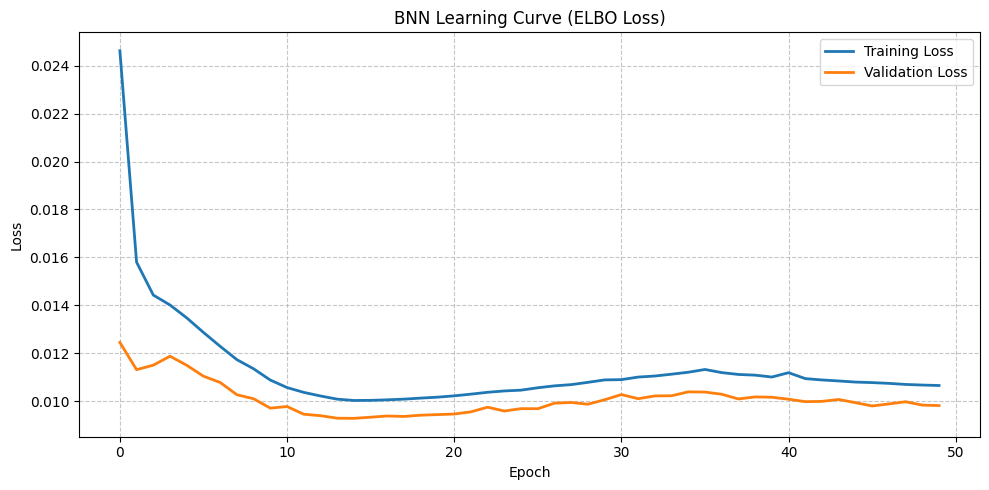

In [ ]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")

print(f"Model Input Dimension: {INPUT_DIM}")
print(f"Model Output Dimension: {OUTPUT_DIM}")

# Initializing the Bayesian network (BNN), same dimensions as DNN
bnn_model = models.SpeechBNN(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, output_dim=OUTPUT_DIM, prior_sigma=PRIOR_STD, prior_type=PRIOR_TYPE)

# Running the training process
print("\n--- Starting BNN Training ---")
bnn_history = train.train_bnn(
    model=bnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    max_beta=MAX_BETA,
    mc_samples=MC_SAMPLES_TRAIN,
    device=device
)

# Save the trained parameters
torch.save(bnn_model.state_dict(), os.path.join(models_dir, 'bnn_model.pth'))
print("BNN model saved successfully to the 'models' directory.")

# Plotting the learning curve (ELBO Loss)
utils.plot_learning_curve(bnn_history, title='BNN Learning Curve (ELBO Loss)')

## BNN Example: Inference and Audio Reconstruction

Same as in the DNN

In [ ]:
# Select same sample from the test set
test_sample = test_data[0]

# Run inference
predicted_audio = inference.run_inference(bnn_model, test_sample, CONTEXT_FRAMES, MC_SAMPLES_INFERENCE, HOP_LENGTH, device)

# Display interactive audio players
print(f"--- Audio Results (SNR: {test_sample['snr']} dB) ---")
print("1. Clean Original Speech:")
display(ipd.Audio(test_sample['clean'], rate=SR))

print("2. Noisy Speech (Input):")
display(ipd.Audio(test_sample['mixed'], rate=SR))

print("3. BNN Enhanced Speech (Output):")
display(ipd.Audio(predicted_audio, rate=SR))

--- Audio Results (SNR: 0 dB) ---
1. Clean Original Speech:


2. Noisy Speech (Input):


3. BNN Enhanced Speech (Output):


# Objective Model Evaluation

To rigorously compare the performance of the DNN and the BNN, we evaluate them on the validation set using two standard objective metrics:
* **PESQ (Perceptual Evaluation of Speech Quality):** Measures the overall *perceptual quality* of the speech. Scores range from -0.5 to 4.5, with higher scores indicating better quality.
* **STOI (Short-Time Objective Intelligibility):** Measures the *intelligibility* of the speech. Scores range from 0.0 to 1.0, with higher scores indicating that the speech is easier to understand.

The evaluation process runs inference on each test sample and compares the denoised output directly to the clean reference waveform. For the BNN, predictions are generated by averaging multiple stochastic forward passes (Monte Carlo sampling) to leverage its predictive uncertainty.

In [ ]:
# Define the models
models_to_evaluate = {
    'DNN': dnn_model,
    'BNN': bnn_model,
}

# Objective Metrics Evaluation
print("Running comprehensive evaluation...")
final_snr_results_df = metrics.evaluate_multiple_models_by_snr(
    dataset=val_data,
    models_dict=models_to_evaluate,
    context_frames=CONTEXT_FRAMES,
    mc_samples_inference=MC_SAMPLES_INFERENCE,
    hop_length=HOP_LENGTH,
    device=device,
    sr=SR
)

display(final_snr_results_df)

Running comprehensive evaluation...


Evaluating Dataset by SNR:   0%|          | 0/90 [00:00<?, ?it/s]

,SNR (dB),Model,PESQ Score,STOI Score
0,0,Noisy Baseline,1.212,0.783
1,0,DNN,1.316,0.811
2,0,BNN,1.303,0.747
3,5,Noisy Baseline,1.359,0.836
4,5,DNN,1.453,0.853
5,5,BNN,1.327,0.782
6,10,Noisy Baseline,1.636,0.905
7,10,DNN,1.589,0.883
8,10,BNN,1.367,0.806


### Short Analysis

Typically, the standard DNN performs well at higher SNRs, but its deterministic nature makes it prone to overconfident, erroneous predictions when faced with heavy wind noise. The Bayesian Neural Network (BNN) with a Gaussian prior successfully introduces stochasticity and extreme sparsity (over 80%), preventing overfitting. However, this massive regularization slightly degrades the raw objective scores like PESQ.

**Next Steps: Heavy-Tailed Priors and Tuning:**

To close the performance gap, we will evaluate a Laplace prior. While standard Gaussian priors aggressively push weights towards zero, a Laplace prior (L1-like regularization) might offer a different weight distribution profile. Furthermore, we will fine-tune the hyperparameters (reducing MAX_BETA, PRIOR_STD, and LEARNING_RATE) to find a better balance between Bayesian regularization and the MSE reconstruction loss.

Using compute device: cuda
Initializing BNN with LAPLACE prior...

--- Starting BNN (Laplace) Training ---
Epoch [1/50] | ELBO: 0.0234 (MSE: 0.0234, KL(unscaled): 378091.6797) | Beta: 0.00000
Epoch [2/50] | ELBO: 0.0142 (MSE: 0.0133, KL(unscaled): 379323.2654) | Beta: 0.00000
Epoch [3/50] | ELBO: 0.0125 (MSE: 0.0107, KL(unscaled): 368563.4548) | Beta: 0.00000
Epoch [4/50] | ELBO: 0.0117 (MSE: 0.0092, KL(unscaled): 348632.8495) | Beta: 0.00000
Epoch [5/50] | ELBO: 0.0113 (MSE: 0.0083, KL(unscaled): 323199.4356) | Beta: 0.00001
Epoch [6/50] | ELBO: 0.0109 (MSE: 0.0075, KL(unscaled): 293295.7193) | Beta: 0.00001
Epoch [7/50] | ELBO: 0.0106 (MSE: 0.0069, KL(unscaled): 261779.4692) | Beta: 0.00001
Epoch [8/50] | ELBO: 0.0102 (MSE: 0.0065, KL(unscaled): 231437.6544) | Beta: 0.00001
Epoch [9/50] | ELBO: 0.0099 (MSE: 0.0061, KL(unscaled): 204648.2740) | Beta: 0.00001
Epoch [10/50] | ELBO: 0.0096 (MSE: 0.0058, KL(unscaled): 182490.5801) | Beta: 0.00001
Epoch [11/50] | ELBO: 0.0094 (MSE: 0.0055,

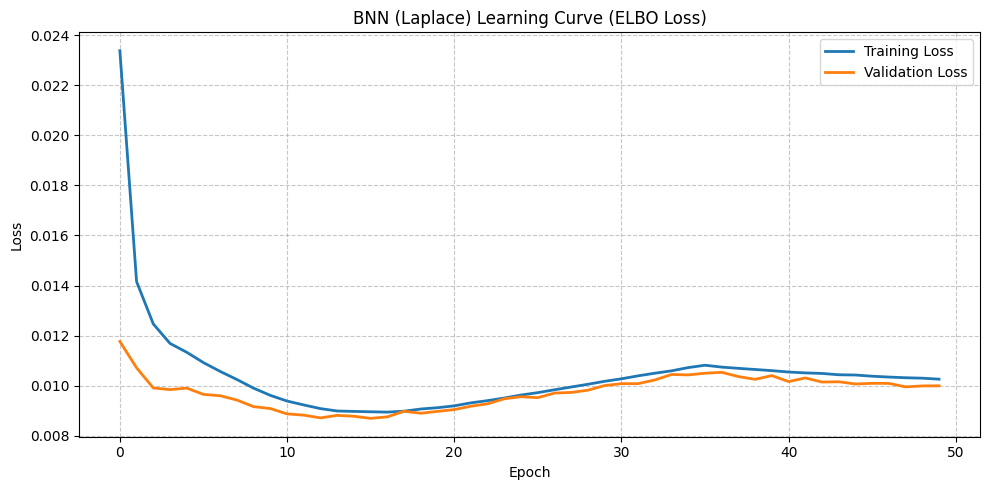

In [ ]:
# Update Constants
PRIOR_TYPE = 'laplace'
MAX_BETA = 0.00005

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")

print(f"Initializing BNN with {PRIOR_TYPE.upper()} prior...")
bnn_laplace_model = models.SpeechBNN(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    prior_sigma=PRIOR_STD,
    prior_type=PRIOR_TYPE
)

print("\n--- Starting BNN (Laplace) Training ---")
bnn_laplace_history = train.train_bnn(
    model=bnn_laplace_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    max_beta=MAX_BETA,
    mc_samples=MC_SAMPLES_TRAIN,
    device=device
)


# Save
torch.save(bnn_laplace_model.state_dict(), os.path.join(models_dir, f'bnn_{PRIOR_TYPE}_model.pth'))
print(f"Model saved successfully to models/bnn_{PRIOR_TYPE}_model.pth")

# Plot the learning curve
utils.plot_learning_curve(bnn_laplace_history, title=f'BNN ({PRIOR_TYPE.capitalize()}) Learning Curve (ELBO Loss)')

# Sensitivity Check - Prior Parameters

A small manual test, COLAB limitations on aggressive hyperparameter tuning...

Using compute device: cuda
Initializing BNN with LAPLACE prior...

--- Starting BNN (check) Training ---
Epoch [1/50] | ELBO: 0.0493 (MSE: 0.0493, KL(unscaled): 292195.6128) | Beta: 0.00000
Epoch [2/50] | ELBO: 0.0288 (MSE: 0.0284, KL(unscaled): 293210.6633) | Beta: 0.00000
Epoch [3/50] | ELBO: 0.0245 (MSE: 0.0237, KL(unscaled): 293276.5207) | Beta: 0.00000
Epoch [4/50] | ELBO: 0.0222 (MSE: 0.0210, KL(unscaled): 292071.1275) | Beta: 0.00000
Epoch [5/50] | ELBO: 0.0207 (MSE: 0.0191, KL(unscaled): 289166.1211) | Beta: 0.00000
Epoch [6/50] | ELBO: 0.0196 (MSE: 0.0176, KL(unscaled): 284088.9929) | Beta: 0.00000
Epoch [7/50] | ELBO: 0.0188 (MSE: 0.0165, KL(unscaled): 276525.2885) | Beta: 0.00001
Epoch [8/50] | ELBO: 0.0182 (MSE: 0.0156, KL(unscaled): 266739.9809) | Beta: 0.00001
Epoch [9/50] | ELBO: 0.0176 (MSE: 0.0148, KL(unscaled): 255325.4133) | Beta: 0.00001
Epoch [10/50] | ELBO: 0.0172 (MSE: 0.0141, KL(unscaled): 243115.1579) | Beta: 0.00001
Epoch [11/50] | ELBO: 0.0167 (MSE: 0.0135, K

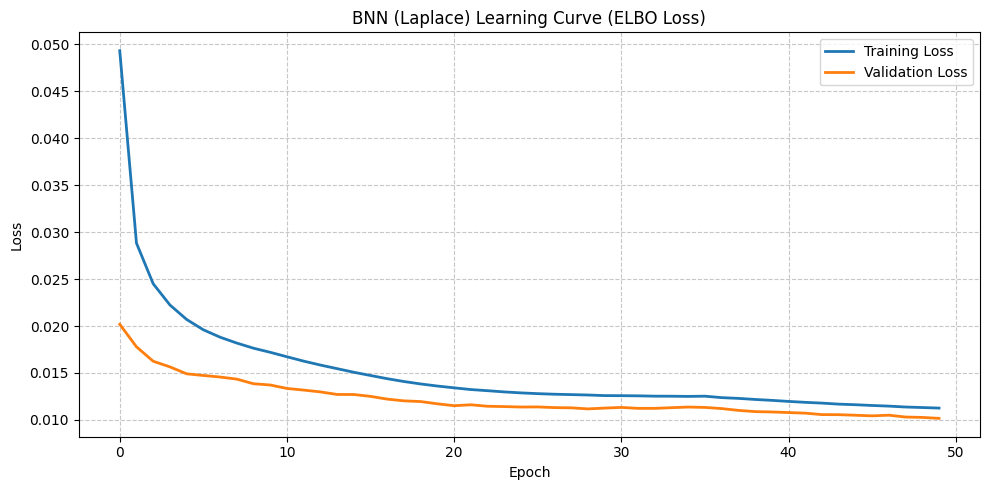

In [ ]:
# Update Constants
PRIOR_TYPE = 'laplace'
PRIOR_STD = 0.05        # Tightens the prior around zero, pushing to shrink weights more aggressively
MAX_BETA = 0.00003      # Reduces KL influence so the MSE term has slightly more weight under the stricter prior
LEARNING_RATE = 1e-4    # Lowers the step size to stabilize training under the stronger prior constraints


# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")

print(f"Initializing BNN model...")
bnn_check_model = models.SpeechBNN(
    input_dim=INPUT_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
    prior_sigma=PRIOR_STD,
    prior_type=PRIOR_TYPE
)

print("\n--- Starting BNN (check) Training ---")
bnn_check_history = train.train_bnn(
    model=bnn_check_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    max_beta=MAX_BETA,
    mc_samples=MC_SAMPLES_TRAIN,
    device=device
)

# Save
torch.save(bnn_check_model.state_dict(), os.path.join(models_dir, f'bnn_check_model.pth'))
print(f"Model saved successfully to models/bnn_check_model.pth")

# Plot the learning curve
utils.plot_learning_curve(bnn_check_history, title=f'BNN (check) Learning Curve (ELBO Loss)')


### OPTIONAL: Load saved baseline models

In [ ]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")

# Initialize fresh models
dnn_model = models.SpeechDNN(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, output_dim=OUTPUT_DIM)
bnn_model = models.SpeechBNN(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, output_dim=OUTPUT_DIM, prior_sigma=PRIOR_STD, prior_type='gaussian')
bnn_laplace_model = models.SpeechBNN(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, output_dim=OUTPUT_DIM, prior_sigma=PRIOR_STD, prior_type='laplace')
bnn_check_model = models.SpeechBNN(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, output_dim=OUTPUT_DIM, prior_sigma=PRIOR_STD, prior_type='laplace')

# Load the saved parameters
dnn_model.load_state_dict(torch.load(os.path.join(models_dir, 'dnn_model.pth')))
bnn_model.load_state_dict(torch.load(os.path.join(models_dir, 'bnn_model.pth')))
bnn_laplace_model.load_state_dict(torch.load(os.path.join(models_dir, 'bnn_laplace_model.pth')))
bnn_check_model.load_state_dict(torch.load(os.path.join(models_dir, 'bnn_check_model.pth')))

# Move to GPU and set to evaluation mode
dnn_model.to(device).eval()
bnn_model.to(device).eval()
bnn_laplace_model.to(device).eval()
bnn_check_model.to(device).eval()
print("Models loaded successfully from the 'models' directory.")

Using compute device: cuda
Models loaded successfully from the 'models' directory.


## Validation Set - Results


In [ ]:
# Define the models we want to compare
models_to_evaluate = {
    'DNN': dnn_model,
    'BNN (Gaussian)': bnn_model,
    'BNN (Laplace)': bnn_laplace_model,
    'BNN (check)': bnn_check_model,
}


# Objective Metrics Evaluation
print("Running comprehensive evaluation on VALIDATON SET...")
check_snr_results_df = metrics.evaluate_multiple_models_by_snr(
    dataset=val_data,
    models_dict=models_to_evaluate,
    context_frames=CONTEXT_FRAMES,
    mc_samples_inference=MC_SAMPLES_INFERENCE,
    hop_length=HOP_LENGTH,
    device=device,
    sr=SR
)

display(check_snr_results_df)

Running comprehensive evaluation...


Evaluating Dataset by SNR:   0%|          | 0/90 [00:00<?, ?it/s]

,SNR (dB),Model,PESQ Score,STOI Score
0,0,Noisy Baseline,1.213,0.790
1,0,DNN,1.319,0.816
2,0,BNN (Gaussian),1.314,0.748
3,0,BNN (Laplace),1.308,0.763
4,0,BNN (check),1.430,0.761
5,5,Noisy Baseline,1.372,0.840
6,5,DNN,1.449,0.857
7,5,BNN (Gaussian),1.328,0.784
8,5,BNN (Laplace),1.356,0.804
9,5,BNN (check),1.493,0.796


# Additional Experiments

### Sparsity Comparison

--- Network Weight Sparsity ---
DNN Sparsity: 15.27%
BNN (Gaussian) Sparsity: 80.29%
BNN (Laplace) Sparsity: 68.90%
BNN (check) Sparsity: 77.67%




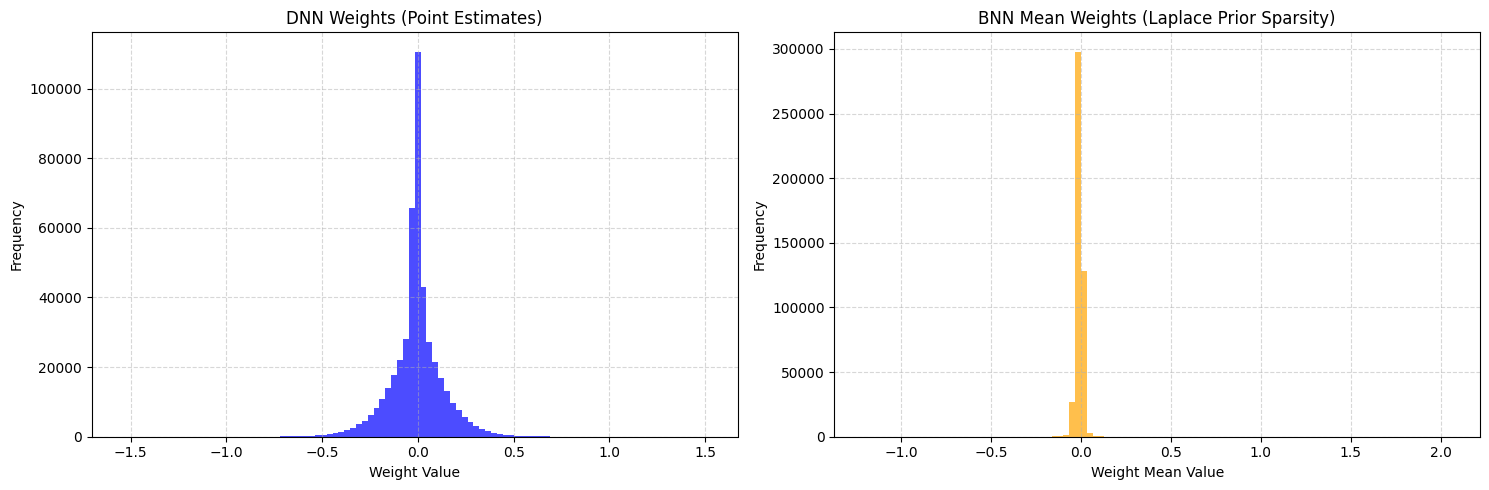

In [ ]:
# Sparsity Evaluation
print("--- Network Weight Sparsity ---")
for name, model in models_to_evaluate.items():
    sparsity = utils.calculate_sparsity(model)
    print(f"{name} Sparsity: {sparsity:.2f}%")

print("\n")

utils.plot_weight_distributions(dnn_model, bnn_laplace_model)

BNN models with a Laplace prior naturally push many weights toward zero, creating a highly sparse structure, while the DNN’s broad bell‑shaped distribution shows it relies on almost all of its parameters. Tightening the prior increased sparsity to 77.67%, meaning the model leaned even more heavily on the prior and zeroed out additional weights.

### Bayesian Advantage - **Certainty Level** (Example)

Generating Uncertainty Spectrogram...


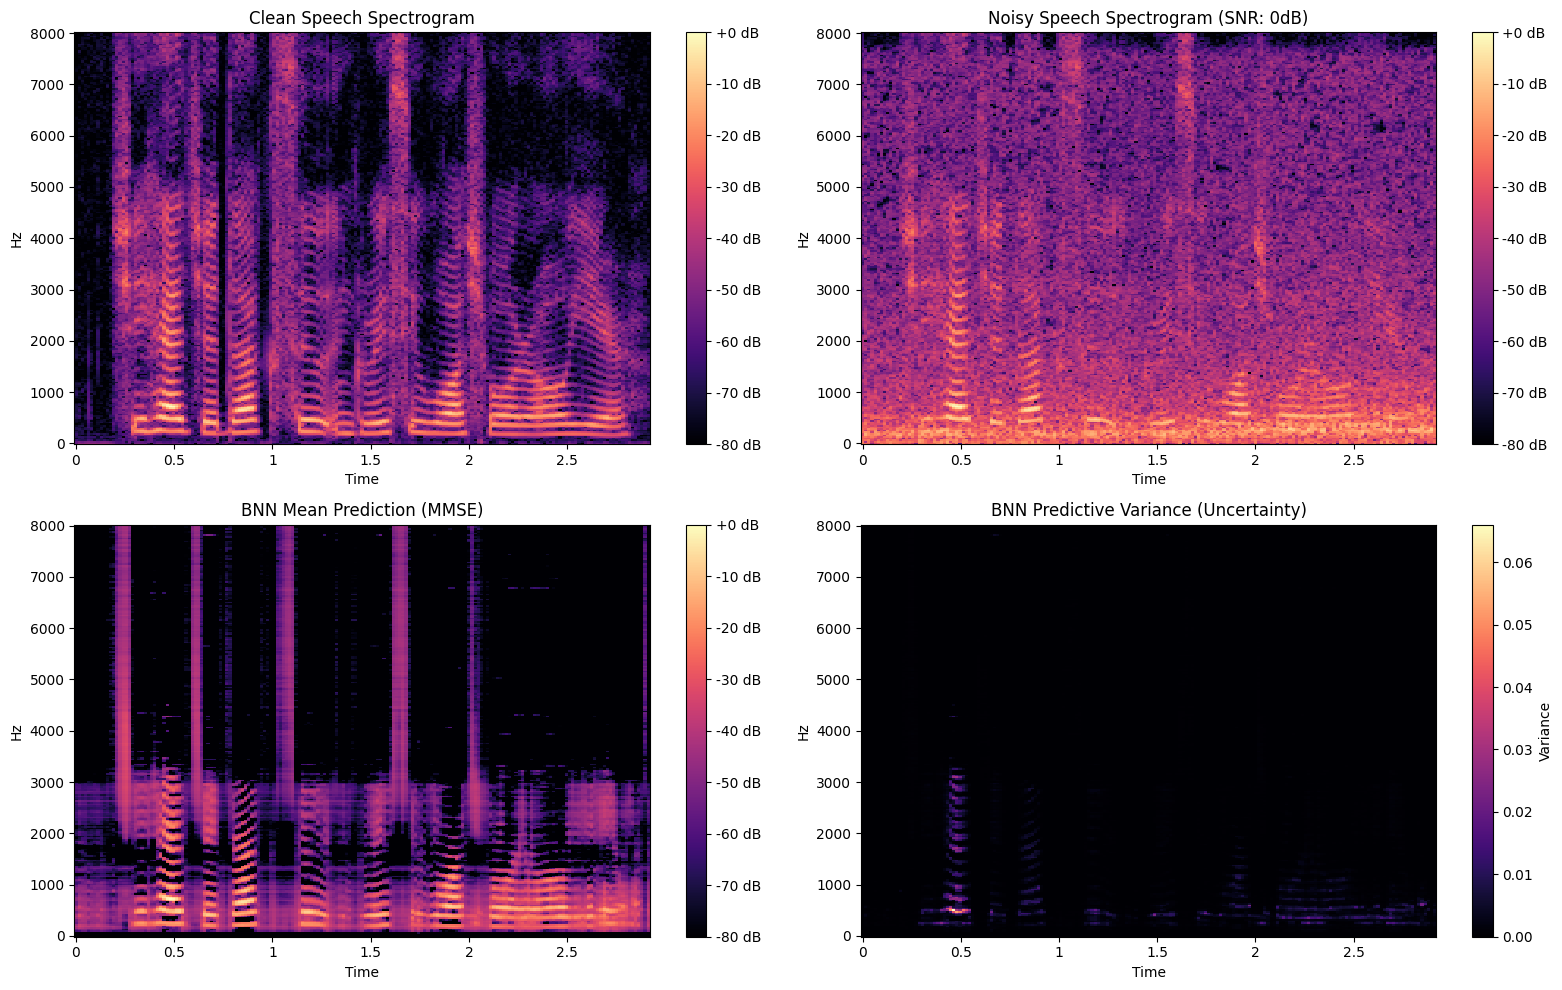

In [ ]:
# Select a challenging 0dB sample from the test set
hard_sample = next(s for s in test_data if s['snr'] == 0)

print("Generating Uncertainty Spectrogram...")
utils.plot_bnn_uncertainty(
    model=bnn_laplace_model,
    sample=hard_sample,
    context_frames=CONTEXT_FRAMES,
    device=device,
    sr=SR,
    hop_length=HOP_LENGTH,
    mc_samples=MC_SAMPLES_INFERENCE
)

The clean speech spectrogram (top‑left) shows clear harmonic structures (formants). When heavy noise is added at 0 dB SNR (top‑right), these structures become almost invisible under the noise.
The BNN’s mean prediction (bottom‑left) successfully reconstructs the speech by removing most of the noise.
The uncertainty map (bottom‑right) highlights where the model is unsure: low variance in noise regions (the model is confident they should be suppressed) and high variance exactly along the speech formants (the model is unsure about their precise amplitude due to the strong noise).



### Out-of-Distribution Analysis

Running Out-of-Distribution (OOD) Comparison Experiment...


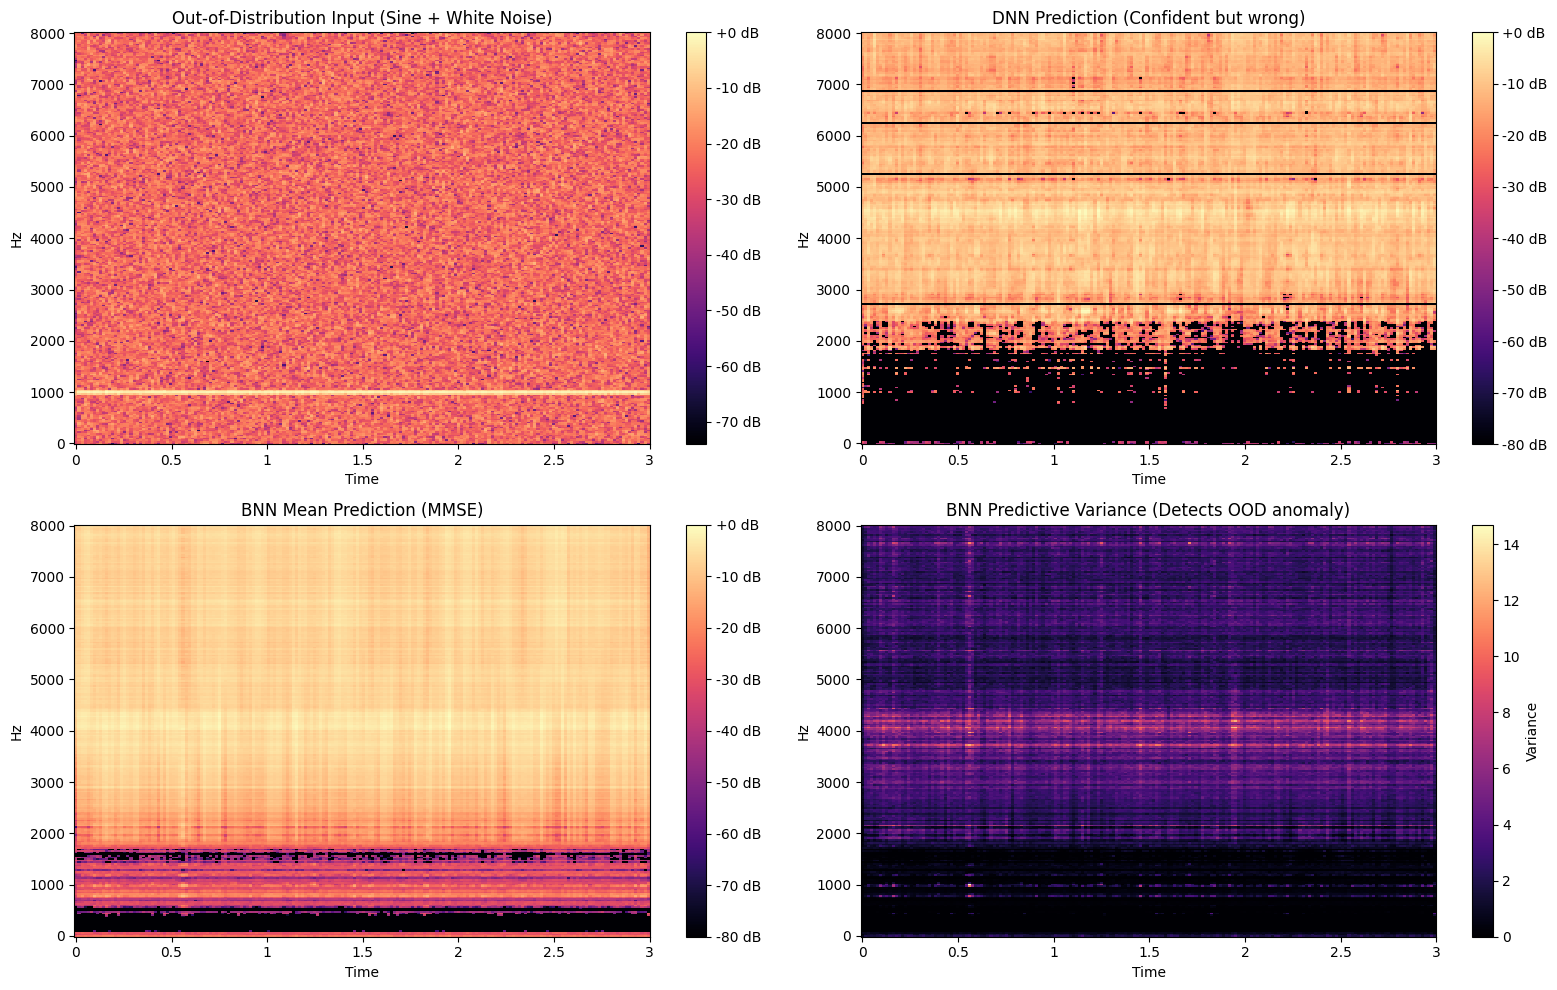

In [ ]:
print("Running Out-of-Distribution (OOD) Comparison Experiment...")
utils.plot_ood_comparison(
    dnn_model=dnn_model,
    bnn_model=bnn_laplace_model,
    context_frames=CONTEXT_FRAMES,
    device=device,
    sr=SR,
    hop_length=HOP_LENGTH,
    mc_samples=MC_SAMPLES_INFERENCE
)



When presented with completely unfamiliar data (a sine wave mixed with white noise), the deterministic DNN *hallucinates a distorted, speech-like spectrogram and outputs it with absolute certainty*, lacking any mechanism to express doubt. Conversely, while the BNN's mean prediction is also distorted, *its predictive variance (bottom-right) spikes dramatically* across all frequencies (reaching values over 14.0). This is demonstrating the BNN's crucial ability to "know what it doesn't know."

# Test Set - Final Results Comparison


In [ ]:
# Define the models we want to compare
models_to_evaluate = {
    'DNN': dnn_model,
    'BNN (Gaussian)': bnn_model,
    'BNN (Laplace)': bnn_laplace_model,
    'BNN (check)': bnn_check_model,
}

# Objective Metrics Evaluation
print("Running comprehensive evaluation on TEST SET...")
check_TEST_results_df = metrics.evaluate_multiple_models_by_snr(
    dataset=test_data,
    models_dict=models_to_evaluate,
    context_frames=CONTEXT_FRAMES,
    mc_samples_inference=MC_SAMPLES_INFERENCE,
    hop_length=HOP_LENGTH,
    device=device,
    sr=SR
)

display(check_TEST_results_df)

Running comprehensive evaluation on TEST SET...


Evaluating Dataset by SNR:   0%|          | 0/90 [00:00<?, ?it/s]

,SNR (dB),Model,PESQ Score,STOI Score
0,0,Noisy Baseline,1.103,0.747
1,0,DNN,1.305,0.808
2,0,BNN (Gaussian),1.236,0.721
3,0,BNN (Laplace),1.277,0.745
4,0,BNN (check),1.360,0.736
5,5,Noisy Baseline,1.233,0.819
6,5,DNN,1.454,0.853
7,5,BNN (Gaussian),1.264,0.769
8,5,BNN (Laplace),1.348,0.793
9,5,BNN (check),1.445,0.776


Insights from the results will be presented in the project report.